# Every rocket launch in history, in plain SQL

**71,541 launches since 1942, of which 7,190 reached orbit.** Sputnik is launch number one of the orbital kind, and the last rows are from this week. The catalogue is a gift for SQL because the interesting questions are all about *order*: the gap between one launch and the next (`LAG`), a rocket's first flights against its later ones (`ROW_NUMBER` per vehicle), and the longest unbroken run of successes (**gaps and islands**, the trick of subtracting two row numbers). Everything else is joins to sites and vehicles, conditional aggregation to pivot decades and orbit types, and running totals. Python only runs the queries and draws the charts.

**Data:** Jonathan McDowell's [General Catalog of Artificial Space Objects](https://planet4589.org/space/gcat/) (launch log plus the sites, organisations and vehicles tables, about 15 MB). Run `python build_db.py` once to download it into a SQLite database, then point `SPACE_DB` at that file.

**Reading the data.** The log holds every launch, including sounding rockets and missile tests, so most questions use the flag `orbital = 1` (launch code starting with O). A launch counts as a *success* only if the catalogue codes it so, and a few launches with an unclear outcome are neither a success nor a failure. The *state* is that of the launching organisation, so Soviet and Russian launches are separate, and some launches of a company based in one country from another are counted under the company. Payload mass is the total mass put in orbit, in tonnes, and is missing for part of the launches. About 4,500 entries (almost all sounding rockets and tests) with a year but no exact date are left out.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("SPACE_DB", "space_launches.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,launches,71541
1,orgs,4138
2,sites,712
3,vehicles,1637


## 1. What counts as a launch?

The log holds far more than orbital launches. A `CASE` labels orbital launches and keeps the catalogue's category for the rest, so the weather rockets, aeronomy probes and missile tests show up next to the satellites.

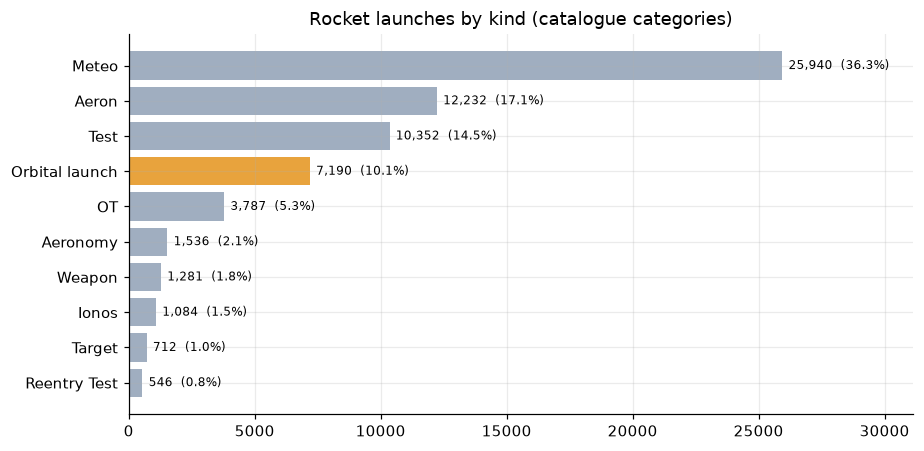

,kind,launches,share_pct,first_year,last_year
0,Meteo,25940,36.3,1960,2022
1,Aeron,12232,17.1,1946,2026
2,Test,10352,14.5,1942,2026
3,Orbital launch,7190,10.1,1957,2026


In [3]:
what = q("""
SELECT CASE WHEN orbital = 1 THEN 'Orbital launch' ELSE category END AS kind,
       COUNT(*)                                               AS launches,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)     AS share_pct,
       MIN(year)                                              AS first_year,
       MAX(year)                                              AS last_year
FROM launches
GROUP BY kind
ORDER BY launches DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(what.kind[::-1], what.launches[::-1], color=[AMBER if k == "Orbital launch" else GREY for k in what.kind[::-1]])
for y, (v, s) in enumerate(zip(what.launches[::-1], what.share_pct[::-1])):
    ax.text(v + 250, y, f"{v:,}  ({s}%)", va="center", fontsize=8)
ax.set_xlim(0, what.launches.max() * 1.2)
ax.set_title("Rocket launches by kind (catalogue categories)")
fig.tight_layout()
plt.show()
what.head(4)

## 2. How many orbital launches per year?

Orbital launches are counted per year with the number of failures, the success rate, a running total with `SUM() OVER` and the change on the previous year with `LAG()`.

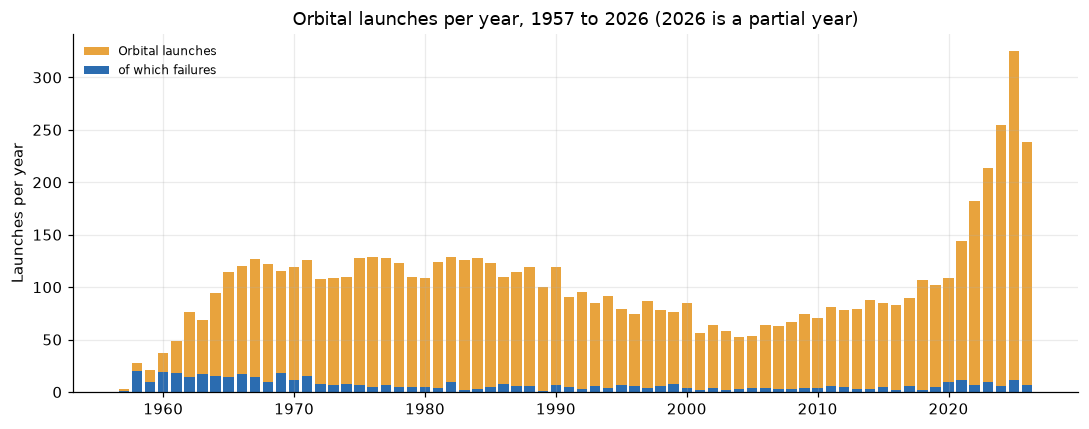

,year,launches,failures,success_pct,total_so_far,change
68,2025,325,11,96.3,6952,70.0
67,2024,255,6,97.6,6627,41.0
69,2026,238,7,96.6,7190,-87.0
66,2023,214,10,95.3,6372,32.0
65,2022,182,7,96.2,6158,38.0


In [4]:
yearly = q("""
WITH yearly AS (
    SELECT year,
           COUNT(*)                   AS launches,
           SUM(outcome = 'success')   AS successes,
           SUM(outcome = 'failure')   AS failures
    FROM launches
    WHERE orbital = 1
    GROUP BY year
)
SELECT year, launches, failures,
       ROUND(100.0 * successes / launches, 1)                   AS success_pct,
       SUM(launches) OVER (ORDER BY year)                       AS total_so_far,
       launches - LAG(launches) OVER (ORDER BY year)            AS change
FROM yearly
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.year, yearly.launches, color=AMBER, label="Orbital launches")
ax.bar(yearly.year, yearly.failures, color=BLUE, label="of which failures")
ax.set_ylabel("Launches per year")
ax.set_title("Orbital launches per year, 1957 to 2026 (2026 is a partial year)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
yearly.sort_values("launches", ascending=False).head(5)

## 3. Who launched, decade by decade?

Conditional aggregation (`SUM(condition)`) pivots the states into columns for each decade. Soviet and Russian launches are put together, the European states and agencies are one group.

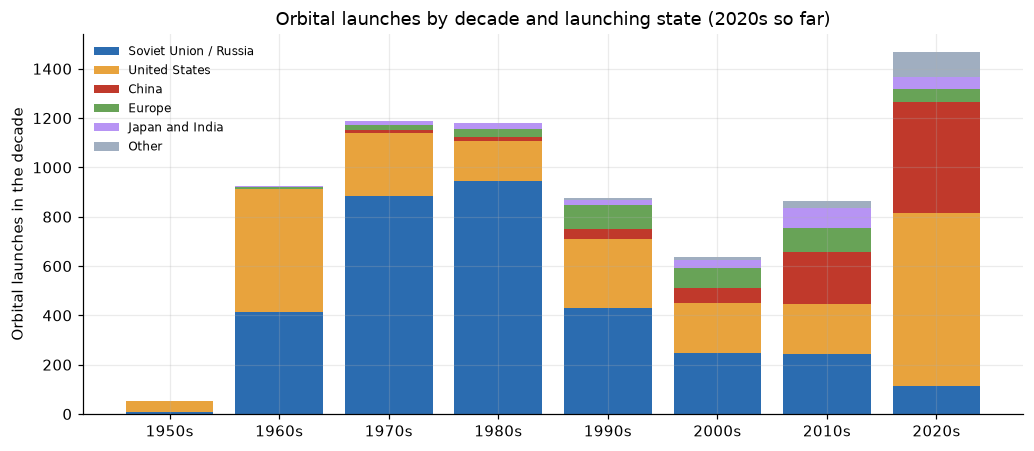

,decade,launches,soviet_russia,usa,china,europe,japan_india,other
0,1950,52,8,44,0,0,0,0
1,1960,923,413,499,0,7,4,0
2,1970,1190,885,254,13,20,18,0
3,1980,1182,946,161,15,33,26,1
4,1990,876,428,282,39,97,22,8
5,2000,636,248,201,64,78,35,10
6,2010,864,242,203,211,98,80,30
7,2020,1467,114,700,451,51,51,100


In [5]:
states = q("""
SELECT (year / 10) * 10                                                                        AS decade,
       COUNT(*)                                                                                AS launches,
       SUM(state IN ('Soviet Union', 'Russia'))                                                AS soviet_russia,
       SUM(state = 'United States')                                                            AS usa,
       SUM(state = 'China')                                                                    AS china,
       SUM(state IN ('France', 'ESA', 'ELDO', 'United Kingdom', 'Italy', 'Germany'))           AS europe,
       SUM(state IN ('Japan', 'India'))                                                        AS japan_india,
       SUM(NOT (state IN ('Soviet Union', 'Russia', 'United States', 'China', 'France', 'ESA', 'ELDO',
                          'United Kingdom', 'Italy', 'Germany', 'Japan', 'India')) OR state IS NULL) AS other
FROM launches
WHERE orbital = 1
GROUP BY decade
ORDER BY decade
""")

cols = ["soviet_russia", "usa", "china", "europe", "japan_india", "other"]
labels = ["Soviet Union / Russia", "United States", "China", "Europe", "Japan and India", "Other"]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bottom = np.zeros(len(states))
for col, lab, color in zip(cols, labels, [BLUE, AMBER, "#c0392b", "#68a357", "#b794f4", GREY]):
    ax.bar(states.decade.astype(str) + "s", states[col], bottom=bottom, label=lab, color=color)
    bottom += states[col].values
ax.set_ylabel("Orbital launches in the decade")
ax.set_title("Orbital launches by decade and launching state (2020s so far)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
states

## 4. Which rockets flew the most?

Launches are joined to the vehicles table to group the many variants (Soyuz-U, Molniya, Vostok and so on) into their rocket family, and `RANK()` orders the families.

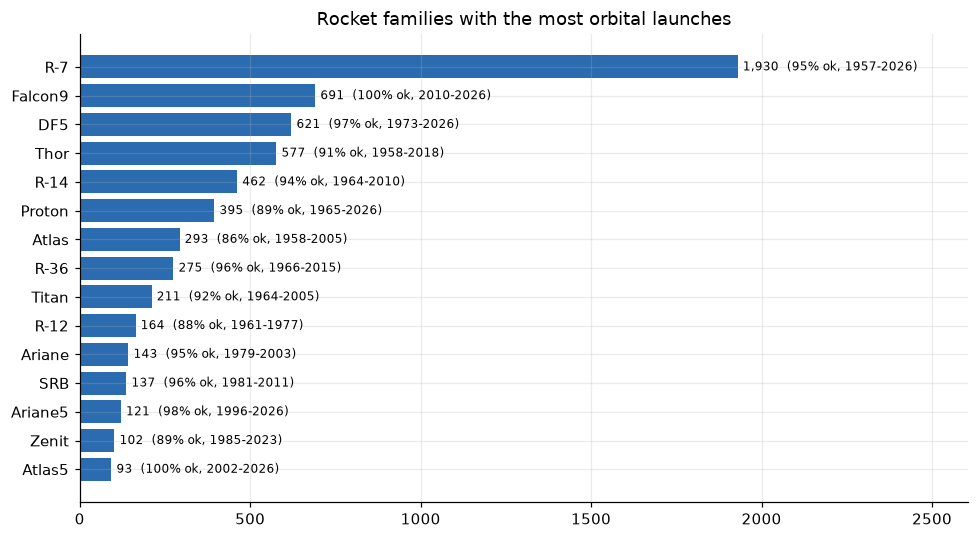

,rank,family,manufacturer,launches,first_year,last_year,success_pct
0,1,R-7,OKB1,1930,1957,2026,95.2
1,2,Falcon9,SPX,691,2010,2026,99.6
2,3,DF5,CALT,621,1973,2026,96.6
3,4,Thor,BOHB,577,1958,2018,91.3
4,5,R-14,OKB586,462,1964,2010,94.4
5,6,Proton,KHRU,395,1965,2026,88.6
6,7,Atlas,GDA,293,1958,2005,86.0
7,8,R-36,OKB586,275,1966,2015,95.6
8,9,Titan,LMA,211,1964,2005,91.9
9,10,R-12,OKB586,164,1961,1977,87.8


In [6]:
families = q("""
WITH f AS (
    SELECT COALESCE(v.family, l.vehicle)  AS family,
           MIN(v.manufacturer)             AS manufacturer,
           COUNT(*)                        AS launches,
           SUM(l.outcome = 'success')      AS successes,
           MIN(l.year)                     AS first_year,
           MAX(l.year)                     AS last_year
    FROM launches l
    LEFT JOIN vehicles v USING (vehicle)
    WHERE l.orbital = 1
    GROUP BY COALESCE(v.family, l.vehicle)
)
SELECT RANK() OVER (ORDER BY launches DESC)  AS rank,
       family, manufacturer, launches, first_year, last_year,
       ROUND(100.0 * successes / launches, 1) AS success_pct
FROM f
ORDER BY launches DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(families.family[::-1], families.launches[::-1], color=BLUE)
for y, (v, s, a, b) in enumerate(zip(families.launches[::-1], families.success_pct[::-1], families.first_year[::-1], families.last_year[::-1])):
    ax.text(v + 15, y, f"{v:,}  ({s:.0f}% ok, {a}-{b})", va="center", fontsize=8)
ax.set_xlim(0, families.launches.max() * 1.35)
ax.set_title("Rocket families with the most orbital launches")
fig.tight_layout()
plt.show()
families

## 5. Do rockets get safer with age?

`ROW_NUMBER() OVER (PARTITION BY vehicle ORDER BY date)` numbers each vehicle's flights. Grouping flights by their number shows how the failure rate changes from a rocket's first launches to its later ones. Only vehicles with at least 20 launches are used, which favours rockets that survived their early years.

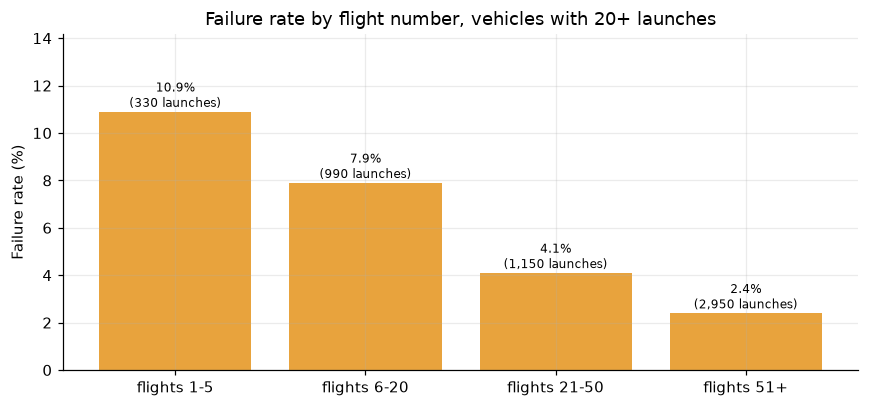

,flight_numbers,launches,vehicles,failures,failure_pct
0,1) flights 1-5,330,66,36,10.9
1,2) flights 6-20,990,66,78,7.9
2,3) flights 21-50,1150,63,47,4.1
3,4) flights 51+,2950,26,72,2.4


In [7]:
reliability = q("""
WITH n AS (
    SELECT vehicle, outcome,
           ROW_NUMBER() OVER (PARTITION BY vehicle ORDER BY launch_date, launch_tag) AS flight_no,
           COUNT(*)     OVER (PARTITION BY vehicle)                                   AS total
    FROM launches
    WHERE orbital = 1
)
SELECT CASE WHEN flight_no <= 5  THEN '1) flights 1-5'
            WHEN flight_no <= 20 THEN '2) flights 6-20'
            WHEN flight_no <= 50 THEN '3) flights 21-50'
            ELSE                      '4) flights 51+' END         AS flight_numbers,
       COUNT(*)                                                    AS launches,
       COUNT(DISTINCT vehicle)                                     AS vehicles,
       SUM(outcome = 'failure')                                    AS failures,
       ROUND(100.0 * SUM(outcome = 'failure') / COUNT(*), 1)       AS failure_pct
FROM n
WHERE total >= 20
GROUP BY flight_numbers
ORDER BY flight_numbers
""")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(reliability.flight_numbers.str[3:], reliability.failure_pct, color=AMBER)
for x, (v, n) in enumerate(zip(reliability.failure_pct, reliability.launches)):
    ax.text(x, v + 0.2, f"{v:.1f}%\n({n:,} launches)", ha="center", fontsize=8)
ax.set_ylim(0, reliability.failure_pct.max() * 1.3)
ax.set_ylabel("Failure rate (%)")
ax.set_title("Failure rate by flight number, vehicles with 20+ launches")
fig.tight_layout()
plt.show()
reliability

## 6. Which launch sites matter?

A join to the sites table gives each site's name (a site that changed country or pad code, such as Baikonur, is grouped by its name), and a window total turns counts into shares. Only orbital launches are counted.

In [8]:
sites = q("""
SELECT s.short_name                                                       AS site,
       GROUP_CONCAT(DISTINCT s.state_code)                                AS states,
       COUNT(*)                                                           AS launches,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)                 AS share_pct,
       MIN(l.year)                                                        AS first_year,
       MAX(l.year)                                                        AS last_year,
       ROUND(100.0 * SUM(l.outcome = 'success') / COUNT(*), 1)            AS success_pct
FROM launches l
JOIN sites s USING (site_code)
WHERE l.orbital = 1
GROUP BY s.short_name
ORDER BY launches DESC
LIMIT 12
""")

sites

,site,states,launches,share_pct,first_year,last_year,success_pct
0,Plesetsk,"SU,RU",1688,23.5,1966,2026,95.9
1,Baykonur,"SU,RU",1496,20.8,1957,2026,91.6
2,Canaveral,US,1012,14.1,1957,2026,92.0
3,Vandenberg,US,883,12.3,1959,2026,93.3
4,Kourou,GUF,329,4.6,1970,2026,94.8
5,Jiuquan,CN,299,4.2,1970,2026,92.3
6,Kennedy,US,265,3.7,1967,2026,97.7
7,Xichang,CN,234,3.3,1984,2026,95.7
8,Taiyuan,CN,161,2.2,1988,2026,96.3
9,Kapustin Yar,SU,101,1.4,1961,2008,84.2


## 7. How often does something fly? Gaps between launches

`LAG()` over all orbital launches in date order gives the days since the previous launch anywhere in the world. Averaged per year, it is the rhythm of spaceflight; `SUM(gap = 0)` counts launches that happened on the same day as the previous one.

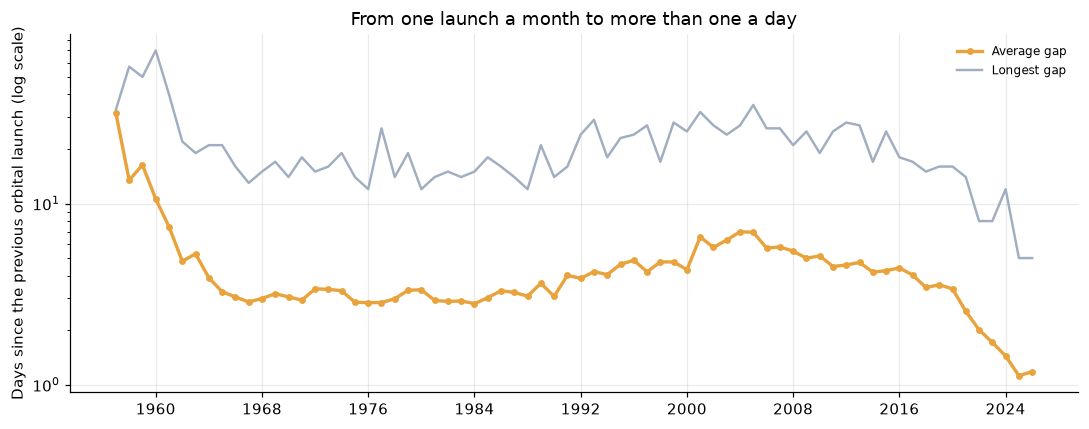

,year,launches,avg_gap_days,longest_gap_days,same_day_as_previous
64,2021,144,2.54,14.0,25
65,2022,182,2.01,8.0,35
66,2023,214,1.71,8.0,39
67,2024,255,1.44,12.0,73
68,2025,325,1.12,5.0,95
69,2026,238,1.18,5.0,71


In [9]:
cadence = q("""
WITH g AS (
    SELECT year, launch_date,
           julianday(launch_date) - julianday(LAG(launch_date) OVER (ORDER BY launch_date, launch_tag)) AS gap_days
    FROM launches
    WHERE orbital = 1
)
SELECT year,
       COUNT(*)                   AS launches,
       ROUND(AVG(gap_days), 2)    AS avg_gap_days,
       MAX(gap_days)              AS longest_gap_days,
       SUM(gap_days = 0)          AS same_day_as_previous
FROM g
GROUP BY year
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cadence.year, cadence.avg_gap_days, color=AMBER, marker="o", ms=3.5, lw=2.2, label="Average gap")
ax.plot(cadence.year, cadence.longest_gap_days, color=GREY, lw=1.6, label="Longest gap")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_yscale("log")
ax.set_ylabel("Days since the previous orbital launch (log scale)")
ax.set_title("From one launch a month to more than one a day")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
cadence.tail(6)

## 8. How much of the world's flying is SpaceX?

Conditional aggregation again: for each year since 2006, SpaceX's share of all orbital launches, and its share of the total mass put into orbit (where the catalogue has a mass). Starship test flights are listed as orbital launches with a nominal 120-tonne payload each, so they are left out of the tonnes (but not the launch counts).

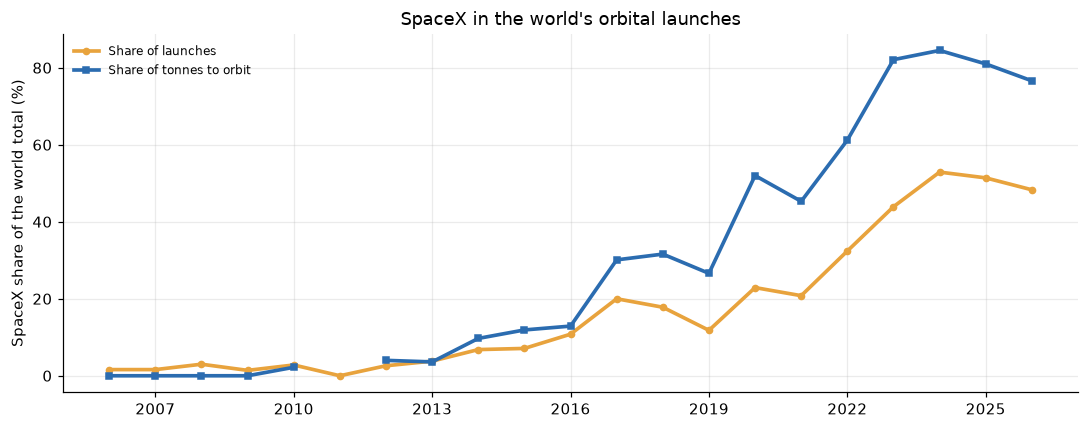

,year,launches,spacex_launches,spacex_launch_share_pct,world_tonnes,spacex_tonnes_share_pct
15,2021,144,30,20.8,858.0,45.3
16,2022,182,59,32.4,1108.0,61.2
17,2023,214,94,43.9,1507.0,82.1
18,2024,255,135,52.9,2098.0,84.5
19,2025,325,167,51.4,2850.0,81.0
20,2026,238,115,48.3,1998.0,76.6


In [10]:
spacex = q("""
WITH l AS (
    SELECT year, agency_code,
           CASE WHEN vehicle LIKE 'Starship%' THEN NULL ELSE payload_tonnes END AS tonnes
    FROM launches
    WHERE orbital = 1 AND year >= 2006
)
SELECT year,
       COUNT(*)                                                                         AS launches,
       SUM(agency_code = 'SPX')                                                         AS spacex_launches,
       ROUND(100.0 * SUM(agency_code = 'SPX') / COUNT(*), 1)                            AS spacex_launch_share_pct,
       ROUND(SUM(tonnes))                                                               AS world_tonnes,
       ROUND(100.0 * SUM(CASE WHEN agency_code = 'SPX' THEN tonnes END) / SUM(tonnes), 1) AS spacex_tonnes_share_pct
FROM l
GROUP BY year
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spacex.year, spacex.spacex_launch_share_pct, color=AMBER, marker="o", ms=4, lw=2.4, label="Share of launches")
ax.plot(spacex.year, spacex.spacex_tonnes_share_pct, color=BLUE, marker="s", ms=4, lw=2.4, label="Share of tonnes to orbit")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylabel("SpaceX share of the world total (%)")
ax.set_title("SpaceX in the world's orbital launches")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
spacex.tail(6)

## 9. Where do satellites go?

The catalogue category of a satellite launch starts with the orbit type (`Sat LEO`, `Sat GTO`...), so `substr()` splits it out. Five-year periods are pivoted with conditional sums.

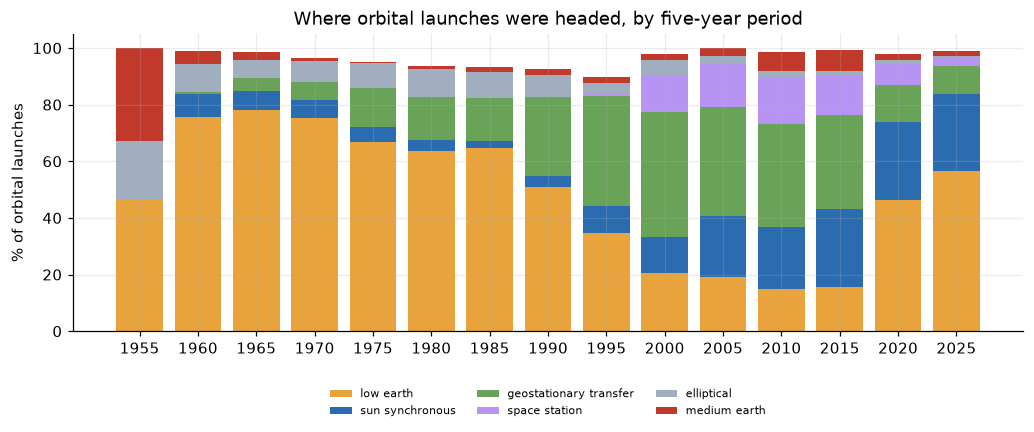

,from_year,launches,low_earth,sun_synchronous,geostationary_transfer,space_station,elliptical,medium_earth
11,2010,397,59,87,145,65,9,26
12,2015,467,73,128,155,67,6,35
13,2020,904,420,248,118,67,13,19
14,2025,563,318,154,55,19,2,9


In [11]:
orbits = q("""
SELECT (year / 5) * 5                                                       AS from_year,
       COUNT(*)                                                             AS launches,
       SUM(substr(category, 5, 3) = 'LEO')                                  AS low_earth,
       SUM(substr(category, 5, 3) = 'SSO')                                  AS sun_synchronous,
       SUM(substr(category, 5, 3) IN ('GTO', 'GEO', 'STO', 'MTO'))          AS geostationary_transfer,
       SUM(substr(category, 5, 3) = 'ISS')                                  AS space_station,
       SUM(substr(category, 5, 3) IN ('MOL', 'HEO', 'EEO'))                 AS elliptical,
       SUM(substr(category, 5, 3) = 'MEO')                                  AS medium_earth
FROM launches
WHERE orbital = 1
GROUP BY from_year
ORDER BY from_year
""")

cols = ["low_earth", "sun_synchronous", "geostationary_transfer", "space_station", "elliptical", "medium_earth"]
share = orbits[cols].div(orbits.launches, axis=0) * 100
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bottom = np.zeros(len(orbits))
for col, color in zip(cols, [AMBER, BLUE, "#68a357", "#b794f4", GREY, "#c0392b"]):
    ax.bar(orbits.from_year.astype(str), share[col], bottom=bottom, label=col.replace("_", " "), color=color)
    bottom += share[col].values
ax.set_ylabel("% of orbital launches")
ax.set_title("Where orbital launches were headed, by five-year period")
ax.legend(frameon=False, fontsize=7, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
plt.show()
orbits.tail(4)

## 10. Longest unbroken runs of success

Gaps and islands: within each vehicle, subtract the row number among the same outcome from the overall row number. Consecutive launches with the same outcome get the same difference, so grouping by it gives the runs. The longest runs of successes are listed, with whether the run was ended by a failure or simply reaches the vehicle's last flight (which includes retired rockets).

In [12]:
streaks = q("""
WITH o AS (
    SELECT vehicle, launch_date, outcome,
           ROW_NUMBER() OVER (PARTITION BY vehicle ORDER BY launch_date, launch_tag)          AS rn,
           ROW_NUMBER() OVER (PARTITION BY vehicle, outcome ORDER BY launch_date, launch_tag) AS rn_outcome
    FROM launches
    WHERE orbital = 1
),
runs AS (
    SELECT vehicle, rn - rn_outcome AS grp, COUNT(*) AS run_length,
           MIN(launch_date) AS from_date, MAX(launch_date) AS to_date
    FROM o
    WHERE outcome = 'success'
    GROUP BY vehicle, grp
)
SELECT vehicle, run_length, from_date, to_date,
       CASE WHEN to_date = (SELECT MAX(launch_date) FROM launches x WHERE x.vehicle = runs.vehicle AND x.orbital = 1)
            THEN 'run reaches the last flight' ELSE 'ended by a non-success' END AS status
FROM runs
ORDER BY run_length DESC
LIMIT 10
""")

streaks

,vehicle,run_length,from_date,to_date,status
0,Falcon 9,334,2024-07-27,2026-10-01,run reaches the last flight
1,Falcon 9,318,2017-01-14,2024-07-08,ended by a non-success
2,Chang Zheng 2D,102,1992-08-09,2026-09-19,run reaches the last flight
3,Tsiklon-2,92,1973-12-27,2006-06-25,run reaches the last flight
4,Soyuz-U,89,1983-10-14,1986-02-26,ended by a non-success
5,Voskhod 11A57,86,1967-09-11,1970-07-09,ended by a non-success
6,Soyuz-U2,72,1982-12-23,1995-09-03,run reaches the last flight
7,Space Shuttle,72,1994-09-09,2011-07-08,run reaches the last flight
8,Ariane 5ECA,69,2005-02-12,2019-11-26,run reaches the last flight
9,Kosmos 11K65M,64,1985-11-28,1991-06-11,ended by a non-success


## What the queries say

- **Only one launch in ten reaches orbit.** Of 71,541 launches since 1942, 7,190 (10.1%) are orbital. The largest group is weather rockets (25,940, or 36%, category "Meteo", between 1960 and 2022), followed by aeronomy probes (12,232) and tests (10,352).
- **Spaceflight spent 50 years at about 100 launches a year, then tripled in five years.** The yearly count was 127 in 1967 and 129 in 1982, fell to 63 in 2007, was still only 90 in 2017, then rose to 182 in 2022, 255 in 2024 and 325 in 2025 (2026 has 238 by early October). Success rates improved from 67% in 1957 to 95-98% in recent years.
- **The rhythm changed.** The average gap between orbital launches anywhere in the world was about 3 days from 1965 to 1990, stretched to 4 to 6 days in the 2000s and 2010s, and fell to 1.12 days in 2025. In 2025 there were 95 launches on the same day as the previous one, against 3 in 2010.
- **The map of who launches changed completely.** In the 1980s the Soviet Union flew 946 of 1,182 orbital launches (80%). In the 2020s so far the United States has 700 of 1,467 (48%), China 451 (31%) and Russia just 114 (8%). Europe has had 78 to 98 launches per decade since the 1990s.
- **One rocket family has flown the most by far.** The R-7 family (Sputnik, Vostok, Molniya, Soyuz) has 1,930 orbital launches since 1957 with a 95.2% success rate, and is still flying. Falcon 9 is second with 691 launches since 2010 and a 99.6% success rate, ahead of a Chinese family from CALT (621, listed as DF5) and the American Thor (577). Atlas (86.0%), R-12 (87.8%) and Proton (88.6%) have the lowest success rates among the top ten families.
- **Rockets do get safer with age, with a caveat.** The failure rate is 10.9% in flights 1 to 5 of a vehicle, 7.9% in flights 6 to 20, 4.1% in flights 21 to 50 and 2.4% beyond 50. This is partly survivorship: only vehicles with at least 20 launches are included, and rockets that failed early were often retired before reaching that number.
- **Four launch complexes dominate.** Plesetsk (1,688 launches, 23.5%), Baikonur (1,496), Cape Canaveral (1,012) and Vandenberg (883) together hold 71% of all orbital launches. Kourou has 329 (4.6%) and the Chinese sites Jiuquan, Xichang and Taiyuan have 694 between them.
- **SpaceX now flies about half of the world's launches and most of its mass.** Its share of orbital launches rose from 10.8% in 2016 to 32% in 2022 and 51% in 2025 (167 of 325). Its share of the tonnes put into orbit is higher (81% in 2025), because its Starlink batches are heavy. The mass total leaves out Starship test flights, which the catalogue lists as orbital launches with a nominal payload of 120 tonnes each.
- **Falcon 9 has the longest runs of success in the catalogue.** It had 318 successful launches in a row from January 2017 to July 2024, was stopped by the Starlink Group 9-3 failure on 12 July 2024, and has since flown 334 in a row (to 1 October 2026). Behind it come Chang Zheng 2D (102, from 1992 to 2026), Tsiklon-2 (92) and Soyuz-U (89 in a row, 1983 to 1986).
- **Where satellites go changed with the business.** Low Earth orbit took 78% of the launches in 1965-69 and only 21% in 2000-04, when geostationary communications satellites dominated. It rebounds to 46% in 2020-24 as constellations are launched, while sun-synchronous orbits grew from almost nothing to 27% of launches.

**Limits.** The state is that of the launching organisation, so a company based abroad is counted under its own state. A few launches have an unclear outcome and count as neither success nor failure. Payload mass is missing for part of the launches, so tonnes are a lower bound. About 4,500 entries without an exact date (mostly sounding rockets) are excluded. The catalogue's own coding decides what counts as orbital: it includes the Starship test flights.
